In [1]:
import os, sys
import numpy as np
import pandas as pd
import scanpy as sc
import torch
from torch import nn
import PINN
from PINN import reader, models, pl, tl
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
# from TorchDiffEqPack import odesolve
from torchdiffeq import odeint

os.chdir("/home/wergillius/Project/PINN_dynamics")

import matplotlib.pyplot as plt
import seaborn as sns

ModuleNotFoundError: No module named 'kan'

In [2]:
from torchdiffeq import odeint

In [3]:
from torch.utils.data import DataLoader

In [4]:
# CHANG THIS !!!!!
ckpt_path = "logs/David_cellstates-pseudotime_scaled_multiBnch/pde_singlebranch_twotimepoints/lightning_logs/version_6/checkpoints/epoch=278-total_loss=2.96587873.ckpt"
model_name = ckpt_path.split("/")[2].replace("_tsense","")
model_class = eval(f"models.{model_name}")

In [5]:
pde_model = model_class.load_from_checkpoint(ckpt_path)

In [6]:
device = 'cuda:1'
pde_model = pde_model.to(device)

In [7]:
torch.rand(11)*0.2

tensor([0.0164, 0.1330, 0.0212, 0.1838, 0.1893, 0.1830, 0.0627, 0.1890, 0.1878,
        0.1616, 0.1199])

In [26]:
next(pde_model.g.parameters())

Parameter containing:
tensor([ 0.0527,  0.0818,  0.1861,  0.0138,  0.0431, -0.0230,  0.0284,  0.0812,
         0.1429,  0.2213,  0.0236], requires_grad=True)

# load data

In [9]:
# MODEL CLASS and define model
pde_model = model_class.load_from_checkpoint(ckpt_path)
device = pde_model.device

data_name = ckpt_path.split("/")[1].split("-")[0]
adata = sc.read_h5ad(f"data/{data_name}.h5ad")
timepoints = adata.uns['pop']['t']

cellstate_key = ckpt_path.split("/")[1].split("-")[1].replace("_multiBnch", "")

n_timepoint = 8
n_grid = 300

In [10]:
train_DS = reader.SingleBranch_AnnDS(AnnData=adata, 
                                n_timepoint = n_timepoint,
                                timepoint_key = 'time',
                                cellstate_key=cellstate_key,  #'Actb_Kcnn4_scaled_S'
                                n_grid=n_grid,  
                                log_transform=False,
                                norm_time = False)

def reduce_batchdim(batch):
    # for batch size 1 , remove the batch dimension
    if len(batch) == 1:
        batch = [ts.squeeze(0) for ts in batch[0]]
    return batch
batch_size = 1
train_DL = DataLoader(train_DS, batch_size=batch_size, num_workers=10, shuffle=True, collate_fn=reduce_batchdim)

In [11]:
u_b = torch.from_numpy(train_DS.u_b).clone().float().to(device)
s = train_DS.s.clone().float().to(device)

# simulation

In [12]:
t_list = train_DS.t_b[:,0] / 5

In [13]:
t_list

array([0.2  , 0.216, 0.232, 0.248, 0.264, 0.28 , 0.296, 0.312])

In [14]:
t_list = train_DS.t_b[:,0] / 5

# loss 2 : dynamics 
# init_condition 
u_int_all = [u_b[0].detach().cpu().numpy()]

with torch.no_grad():
	for it in range(len(t_list)-1):
		t1 = t_list[it+1].item()
		t0 = t_list[it].item()

		step_size = np.around((t1 - t0)/15, decimals=1).item() 
		step_size = step_size if step_size > 0 else 0.05

		step_size = min(step_size, 0.4)

		ut0 = u_b[it,:]
		utp1 = u_b[it+1,:]

		# init condition : ut, s in a square, u in a square
		init_condition = (ut0, s)
		u_int, s_int = odeint(
						pde_model.ode_func,
						init_condition,
						torch.tensor([t0,t1]).type(torch.float32).to(device),
						atol=1e-8,
						rtol=1e-8,
						method='midpoint',
						options = {'step_size': step_size}
				)

		# boundary u of  the next timepoint
		u_int = nn.functional.relu(u_int)

		u_int_all.append(u_int[-1].cpu().numpy())

In [15]:
u_int_all = np.stack(u_int_all)

In [16]:
u_int_all

array([[3.13708140e-03, 3.53114610e-03, 3.95638216e-03, ...,
        8.35813918e-10, 5.22098254e-10, 3.23146176e-10],
       [3.14503093e-03, 1.16999475e-02, 3.25424480e-03, ...,
        1.63423363e-03, 0.00000000e+00, 4.06496911e-05],
       [5.68321953e-03, 2.49890815e-02, 5.55884419e-03, ...,
        1.84857213e+00, 2.20611429e+00, 0.00000000e+00],
       ...,
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        0.00000000e+00, 1.33906729e+04, 0.00000000e+00],
       [2.38085771e-03, 4.40311292e-03, 3.23036988e-03, ...,
        1.42131134e+02, 0.00000000e+00, 1.20442314e+01],
       [4.04388469e-04, 0.00000000e+00, 4.78993665e-04, ...,
        0.00000000e+00, 0.00000000e+00, 1.16294594e+02]], dtype=float32)

In [17]:
u_b.sum(axis=1)

tensor([  0.9973,   1.6787,   5.2296,  14.3606,  59.5829, 136.5859, 325.4272,
        951.6102])

In [27]:
np.exp(0.3)

1.3498588075760032

In [18]:
u_b.min(axis=1), u_b.max(axis=1)

(torch.return_types.min(
 values=tensor([3.2315e-10, 1.2110e-04, 1.2091e-03, 1.0335e-03, 8.9478e-05, 2.4498e-03,
         4.6964e-04, 5.0394e-04]),
 indices=tensor([299, 299, 299, 299,   0,   0,   0,   0])),
 torch.return_types.max(
 values=tensor([ 0.0164,  0.0188,  0.0680,  0.2907,  1.5012,  2.0940,  5.1494, 14.8394]),
 indices=tensor([ 30,  26, 110, 124, 136, 143, 142, 140])))

In [21]:
u_int_all.min(axis=1), u_int_all.max(axis=1)

(array([3.2314618e-10, 0.0000000e+00, 0.0000000e+00, 0.0000000e+00,
        0.0000000e+00, 0.0000000e+00, 0.0000000e+00, 0.0000000e+00],
       dtype=float32),
 array([1.6363380e-02, 4.6404957e+01, 8.0735313e+01, 9.4530457e+02,
        1.2399845e+04, 5.0191597e+05, 1.9086688e+05, 3.9823741e+05],
       dtype=float32))

In [25]:
np.log(u_b+1e-10)

tensor([[ -5.7645,  -5.6461,  -5.5324,  ..., -20.7896, -21.1979, -21.5833],
        [ -5.1836,  -5.0821,  -4.9857,  ...,  -8.8245,  -8.9187,  -9.0189],
        [ -5.6731,  -5.5486,  -5.4288,  ...,  -6.5949,  -6.6546,  -6.7179],
        ...,
        [ -6.0118,  -5.8263,  -5.6516,  ...,  -3.6520,  -3.7608,  -3.8752],
        [ -7.6635,  -7.4206,  -7.1857,  ...,  -2.8468,  -2.9531,  -3.0601],
        [ -7.5930,  -7.2666,  -6.9495,  ...,  -2.5523,  -2.7199,  -2.8950]])

In [ ]:
u_int_all

(torch.return_types.min(
 values=tensor([3.2315e-10, 1.2110e-04, 1.2091e-03, 1.0335e-03, 8.9478e-05, 2.4498e-03,
         4.6964e-04, 5.0394e-04]),
 indices=tensor([299, 299, 299, 299,   0,   0,   0,   0])),
 torch.return_types.max(
 values=tensor([ 0.0164,  0.0188,  0.0680,  0.2907,  1.5012,  2.0940,  5.1494, 14.8394]),
 indices=tensor([ 30,  26, 110, 124, 136, 143, 142, 140])))

In [23]:
np.log(u_int_all+1e-10)

array([[ -5.7644625 ,  -5.646133  ,  -5.5324254 , ..., -20.789604  ,
        -21.197924  , -21.583303  ],
       [ -5.7619314 ,  -4.448171  ,  -5.727795  , ...,  -6.416581  ,
        -23.02585   , -10.110517  ],
       [ -5.1702375 ,  -3.6893163 ,  -5.192365  , ...,   0.6144135 ,
          0.79123276, -23.02585   ],
       ...,
       [-23.02585   , -23.02585   , -23.02585   , ..., -23.02585   ,
          9.502314  , -23.02585   ],
       [ -6.0402946 ,  -5.4254436 ,  -5.7351584 , ...,   4.95675   ,
        -23.02585   ,   2.4885857 ],
       [ -7.813134  , -23.02585   ,  -7.643823  , ..., -23.02585   ,
        -23.02585   ,   4.7561264 ]], dtype=float32)

(<Figure size 1800x1800 with 8 Axes>,
 array([<Axes: title={'center': 'day 12.5'}, ylabel='density'>,
        <Axes: title={'center': 'day 13.5'}>,
        <Axes: title={'center': 'day 14.5'}, ylabel='density'>,
        <Axes: title={'center': 'day 15.5'}>,
        <Axes: title={'center': 'day 16.5'}, ylabel='density'>,
        <Axes: title={'center': 'day 17.5'}>,
        <Axes: title={'center': 'day 18.5'}, xlabel='cell state', ylabel='density'>,
        <Axes: title={'center': 'day 19.5'}, xlabel='cell state'>],
       dtype=object))

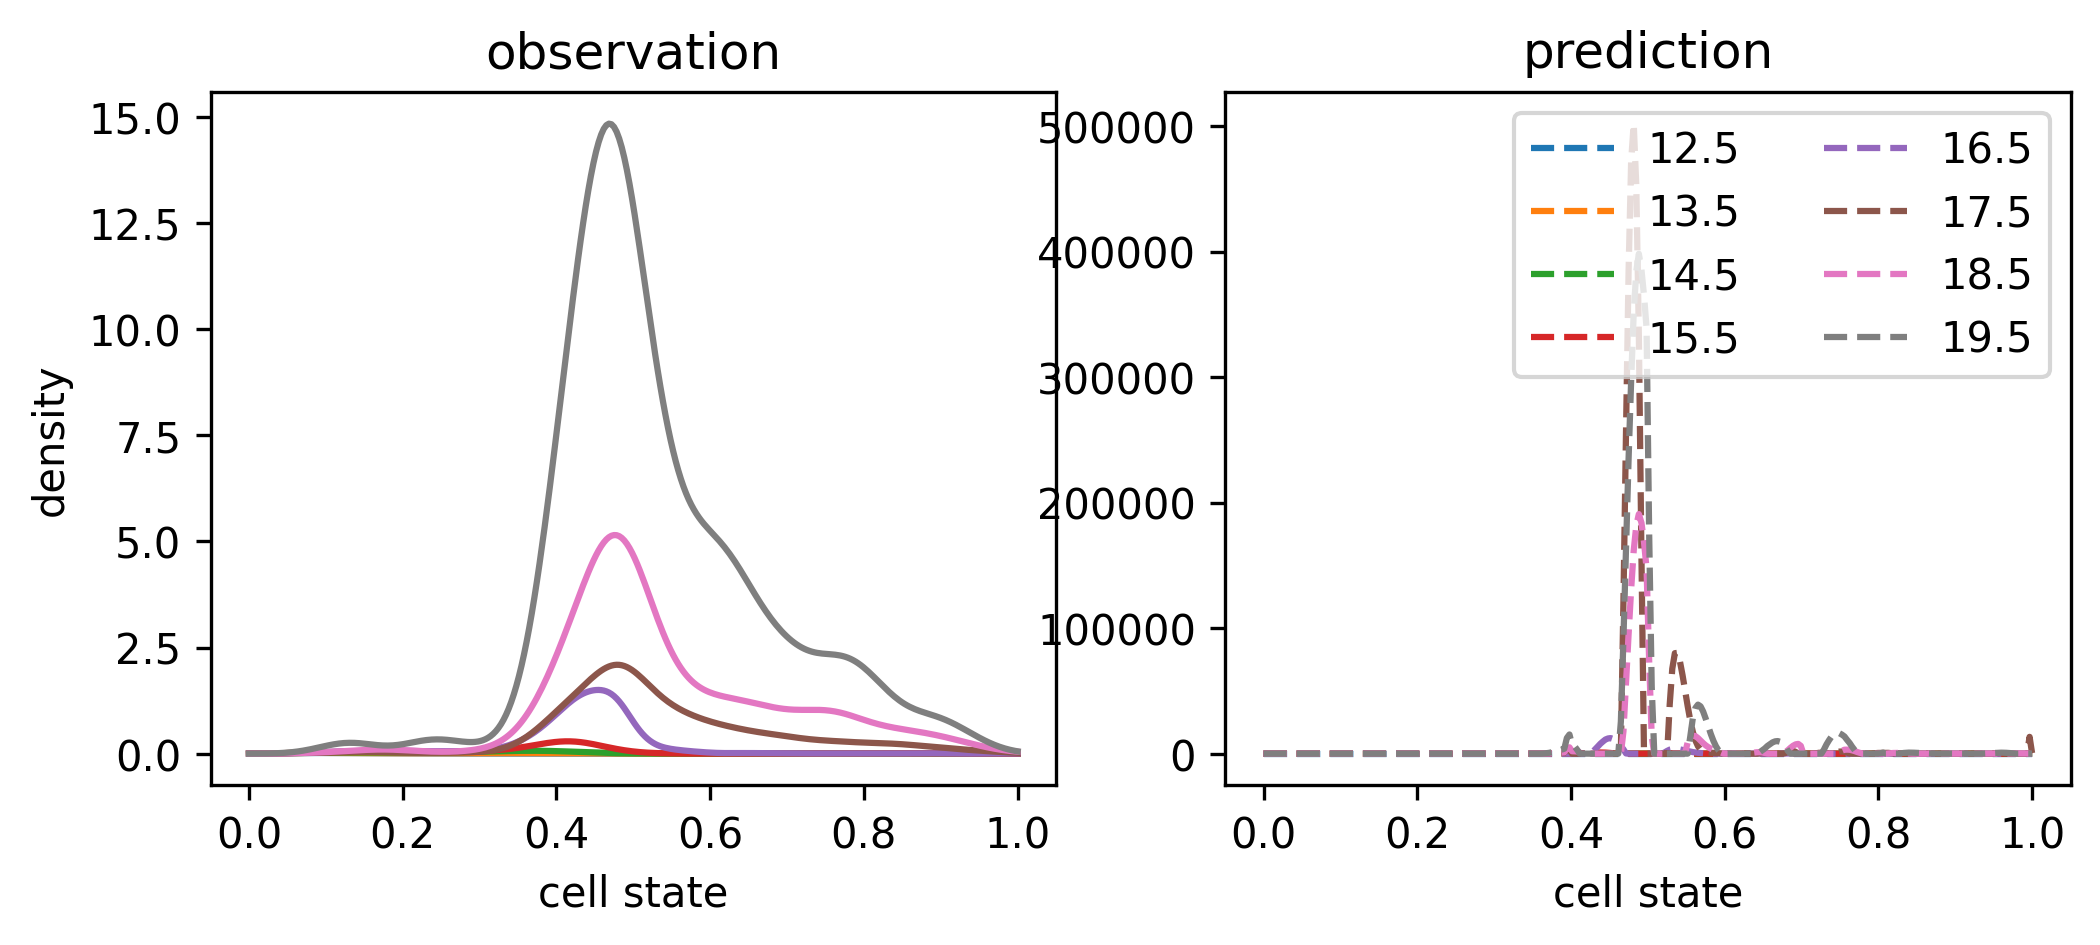

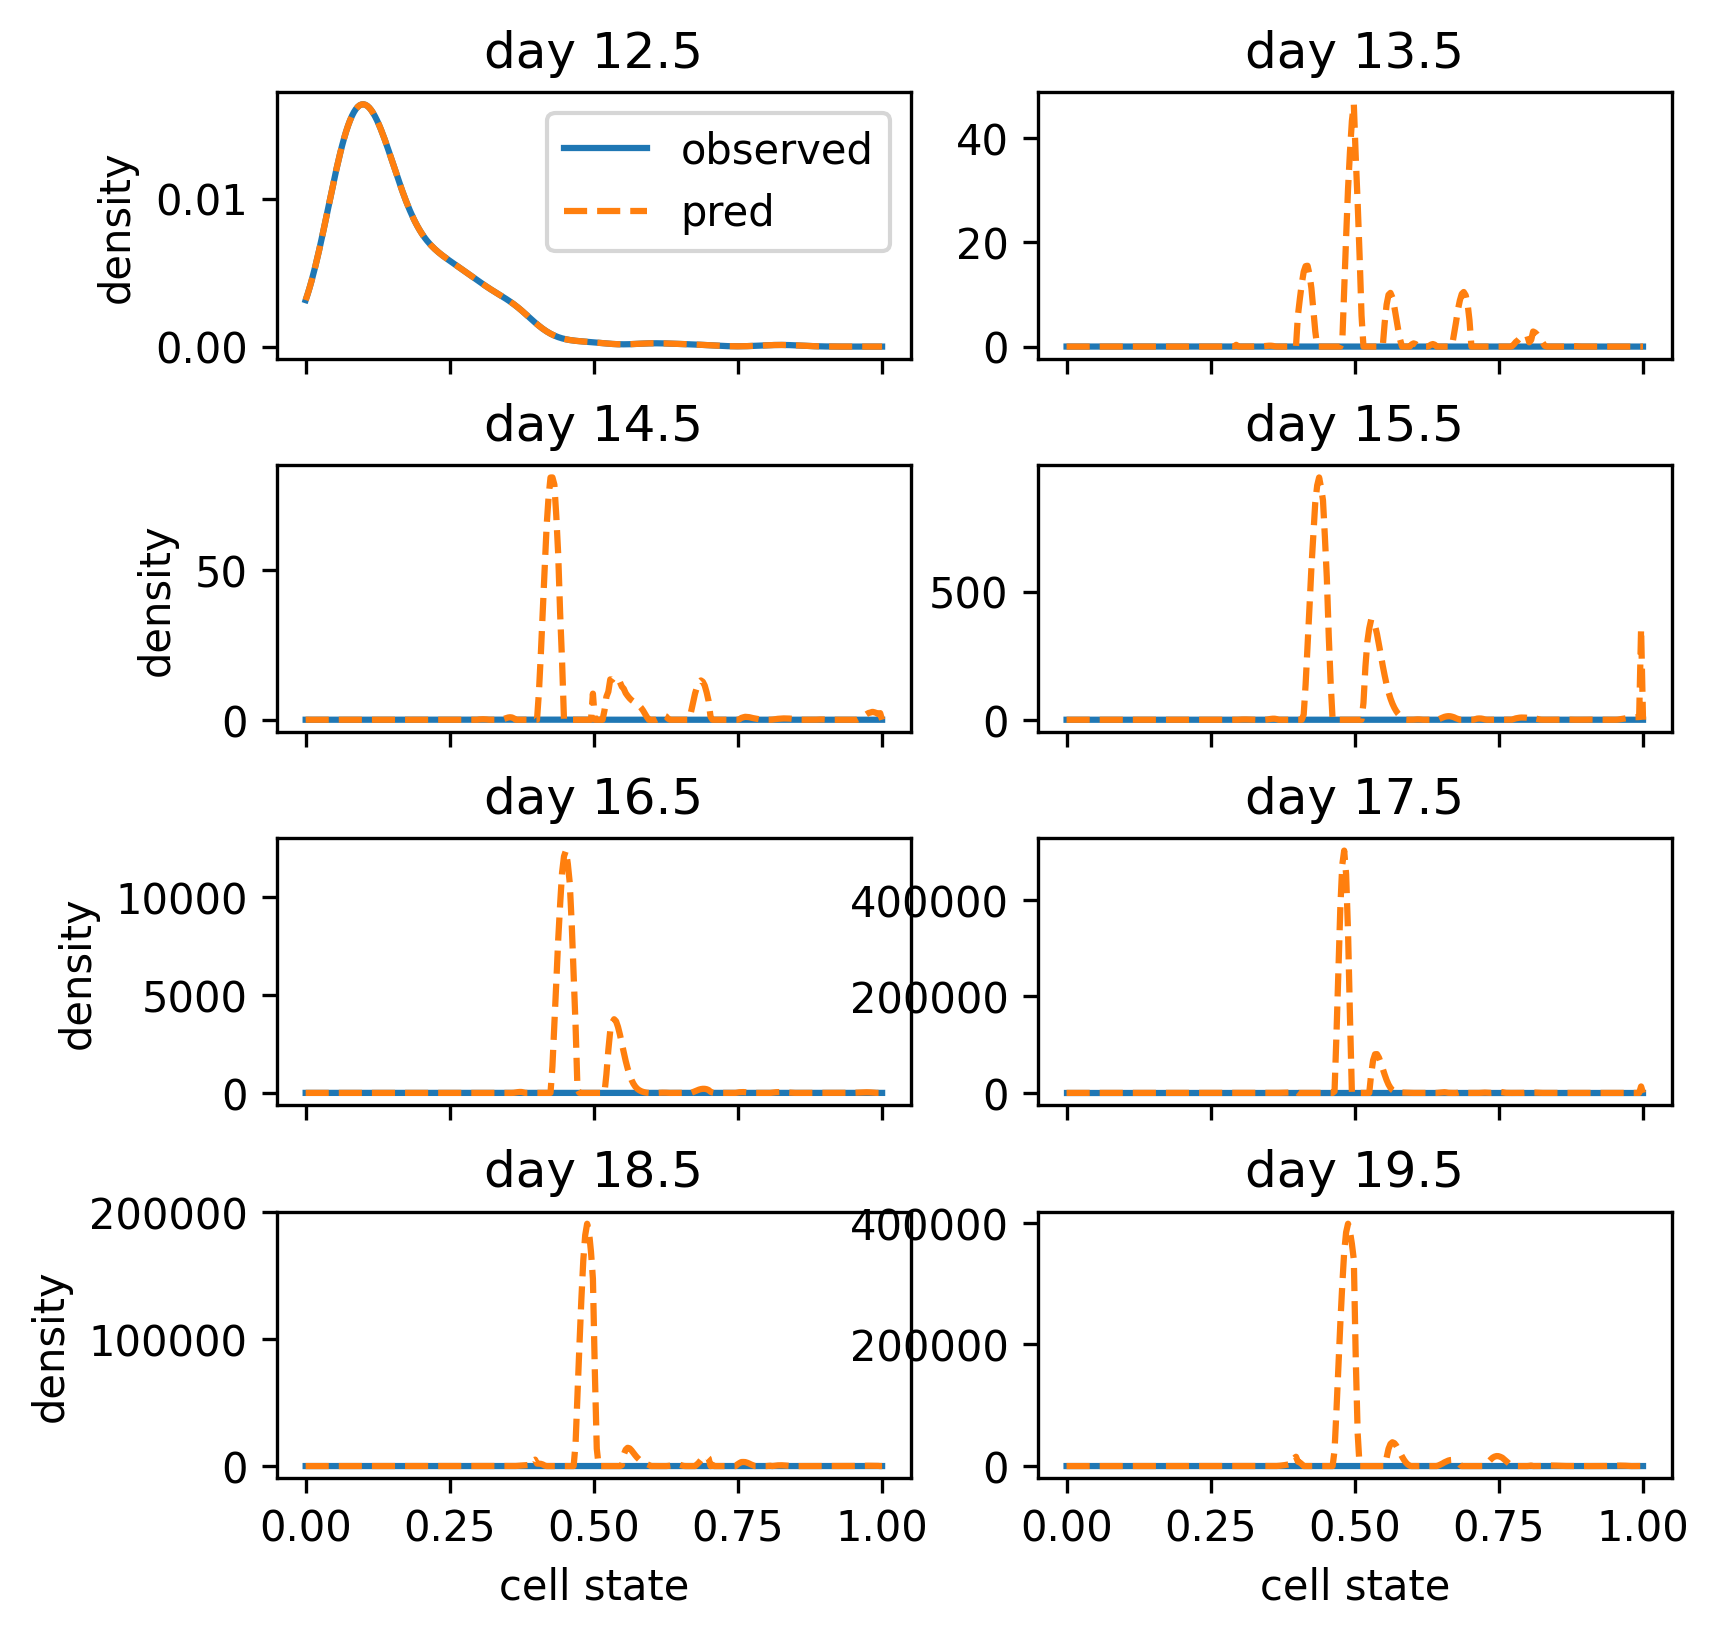

In [19]:
PINN.pl.density_by_time(u_b, u_int_all, train_DS.popD['t'])